# Temporal Memory Analysis

**Read-only diagnostic experiment.** Determines whether the fixed 96-step input window captures temporal dependencies in Alibaba workloads, or whether useful memory exists beyond one day.

> **Scope:** 99 evaluable validation containers. No model training. No Prophet.fit(), GRU, or Ridge fitting in this experiment.

## 1. Experiment overview

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

EXP_DIR = REPO_ROOT / 'experiments/temporal_memory_analysis_2026-07-26_170052'
CONFIG_PATH = EXP_DIR / 'config' / 'temporal_memory_analysis_config.json'

with CONFIG_PATH.open() as fh:
    config = json.load(fh)

print('Experiment:', config['experiment_name'])
print('Timestamp:', config['timestamp'])
print('Containers:', config['n_containers'])
print('Max lag:', config['maximum_lag'])

Experiment: temporal_memory_analysis
Timestamp: 2026-07-26_170052
Containers: 99
Max lag: 672


## 2. Load frozen data

In [2]:
summary_df = pd.read_csv(EXP_DIR / 'tables' / 'cohort_summary.csv')
with (EXP_DIR / 'reports' / 'final_report.json').open() as fh:
    final_report = json.load(fh)
with (EXP_DIR / 'verification' / 'data_integrity.json').open() as fh:
    verification = json.load(fh)

summary_df

,series_type,capture_96_mean_pct,capture_672_mean_pct,lag96_mean_acf,lag192_mean_acf,integrated_autocorr_median
0,cpu_original,39.979471,100.0,0.329489,0.253311,2.354682e-01
1,prophet_residual,49.298225,100.0,0.042035,-0.026347,4.871368e-01
2,hybrid_post_forecast_residual,100.000000,100.0,NaN,NaN,1.110223e-16


## 3. CPU memory analysis

In [3]:
with (EXP_DIR / 'statistics' / 'cpu_original_memory_length.json').open() as fh:
    cpu_memory = json.load(fh)
cpu_memory['distribution']

{'first_insignificant_lag': {'mean': 20.464646464646464,
  'median': 19.0,
  'q25': 4.0,
  'q75': 22.0,
  'iqr': 18.0},
 'half_life_lag': {'mean': 6.565656565656566,
  'median': 2.0,
  'q25': 1.0,
  'q75': 12.0,
  'iqr': 11.0},
 'decorrelation_lag_0p1': {'mean': 18.444444444444443,
  'median': 17.0,
  'q25': 3.0,
  'q75': 20.0,
  'iqr': 17.0},
 'integrated_autocorr_time': {'mean': 0.8009883221603866,
  'median': 0.23546818542018144,
  'q25': -0.027805384026056035,
  'q75': 1.1776059807604065,
  'iqr': 1.2054113647864626}}

## 4. Prophet residual memory

In [4]:
with (EXP_DIR / 'statistics' / 'prophet_residual_memory_length.json').open() as fh:
    prophet_memory = json.load(fh)
prophet_memory['distribution']

{'first_insignificant_lag': {'mean': 30.646464646464647,
  'median': 5.0,
  'q25': 3.0,
  'q75': 43.5,
  'iqr': 40.5},
 'half_life_lag': {'mean': 4.191919191919192,
  'median': 1.0,
  'q25': 1.0,
  'q75': 1.5,
  'iqr': 0.5},
 'decorrelation_lag_0p1': {'mean': 24.626262626262626,
  'median': 4.0,
  'q25': 2.0,
  'q75': 31.5,
  'iqr': 29.5},
 'integrated_autocorr_time': {'mean': 1.1131211322704486,
  'median': 0.4871368037255943,
  'q25': 0.1097757860858446,
  'q75': 1.4041467695845107,
  'iqr': 1.294370983498666}}

## 5. Hybrid residual memory

In [5]:
with (EXP_DIR / 'statistics' / 'hybrid_post_forecast_residual_memory_length.json').open() as fh:
    hybrid_memory = json.load(fh)
hybrid_memory['distribution']

{'first_insignificant_lag': {'mean': 4.373737373737374,
  'median': 2.0,
  'q25': 2.0,
  'q75': 4.5,
  'iqr': 2.5},
 'half_life_lag': {'mean': 2.191919191919192,
  'median': 1.0,
  'q25': 1.0,
  'q75': 2.0,
  'iqr': 1.0},
 'decorrelation_lag_0p1': {'mean': 5.959595959595959,
  'median': 3.0,
  'q25': 2.0,
  'q75': 6.5,
  'iqr': 4.5},
 'integrated_autocorr_time': {'mean': 1.020508032736255e-16,
  'median': 1.1102230246251565e-16,
  'q25': -2.220446049250313e-16,
  'q75': 3.885780586188048e-16,
  'iqr': 6.106226635438361e-16}}

## 6. Long-lag ACF

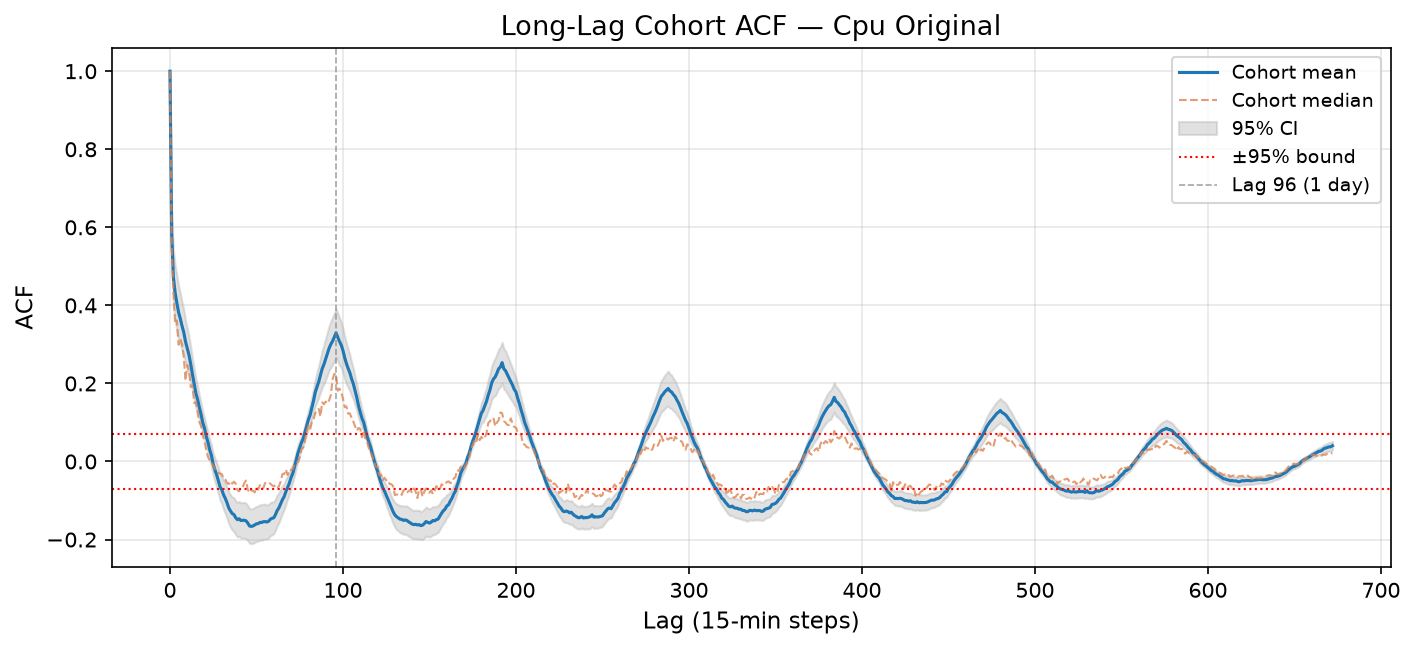

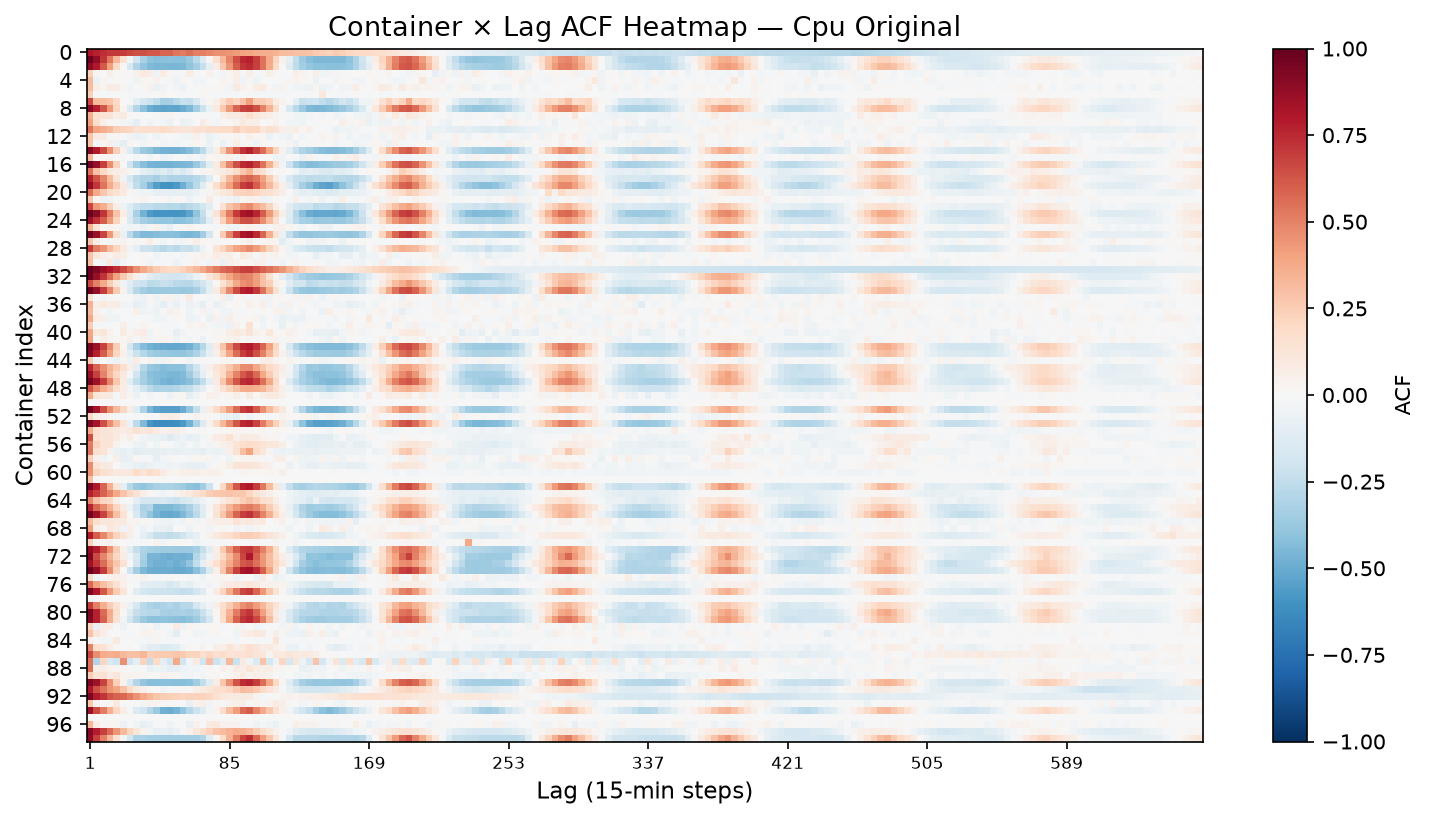

In [6]:
display(Image(filename=str(EXP_DIR / 'plots' / 'cohort_acf_cpu_original.png')))
display(Image(filename=str(EXP_DIR / 'plots' / 'acf_heatmap_cpu_original.png')))

## 7. Long-lag PACF

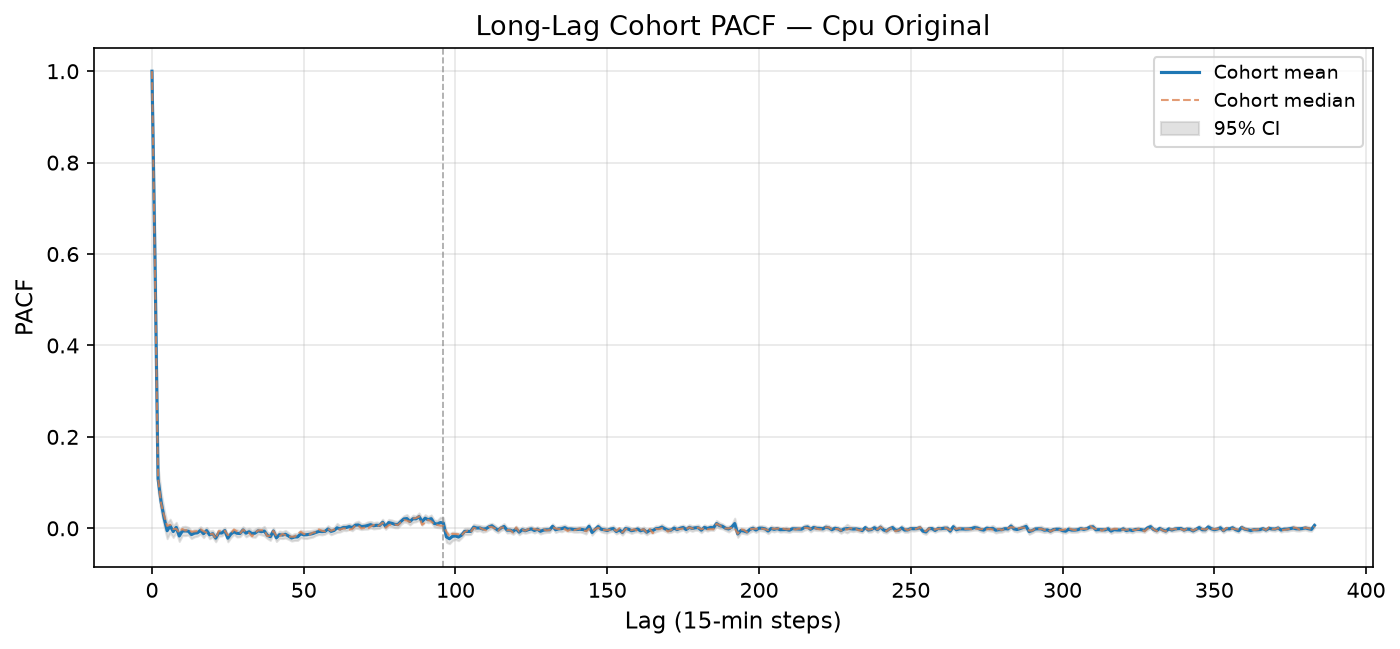

In [7]:
display(Image(filename=str(EXP_DIR / 'plots' / 'cohort_pacf_cpu_original.png')))

## 8. FFT

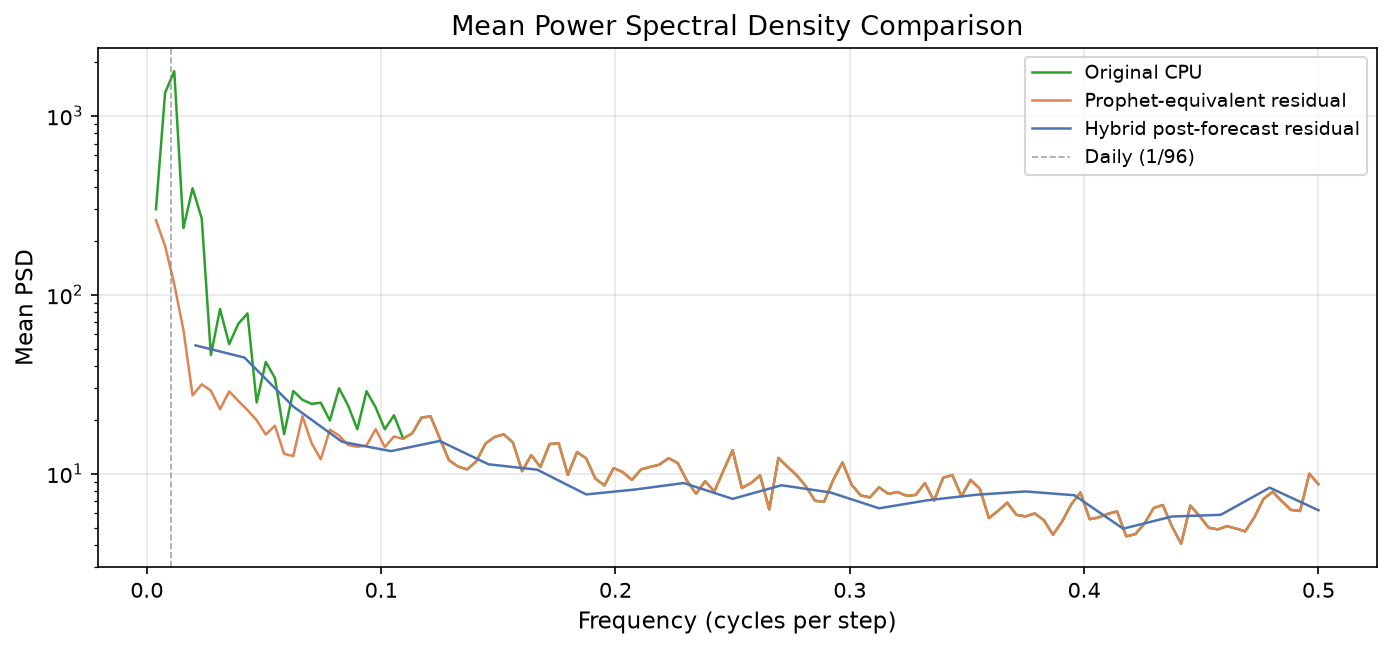

In [8]:
fft_cpu = pd.read_csv(EXP_DIR / 'fft' / 'cpu_original_summary.csv')
fft_cpu[['dominant_period_steps', 'daily_freq_power_fraction']].describe()
display(Image(filename=str(EXP_DIR / 'plots' / 'fft_psd_comparison.png')))

## 9. Daily periodicity

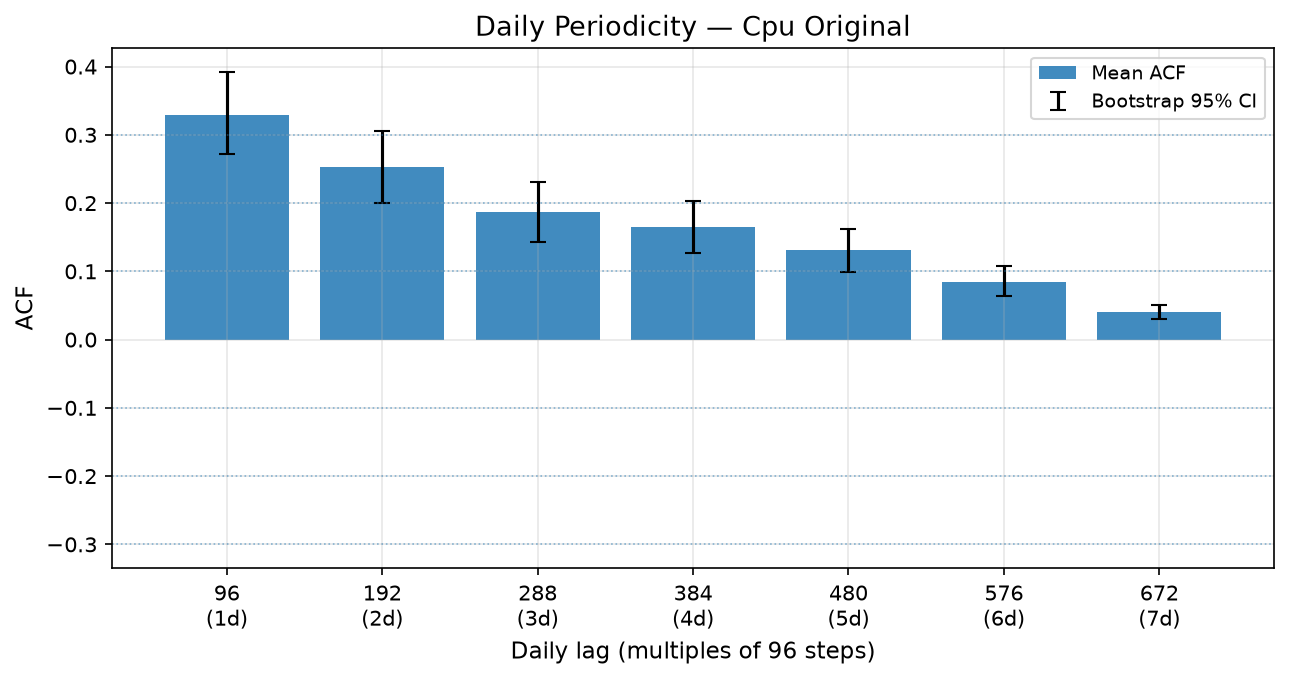

In [9]:
with (EXP_DIR / 'statistics' / 'cpu_original_daily_periodicity.json').open() as fh:
    daily = json.load(fh)
pd.DataFrame(daily['lags']).T
display(Image(filename=str(EXP_DIR / 'plots' / 'daily_periodicity_cpu_original.png')))

## 10. Memory length estimation

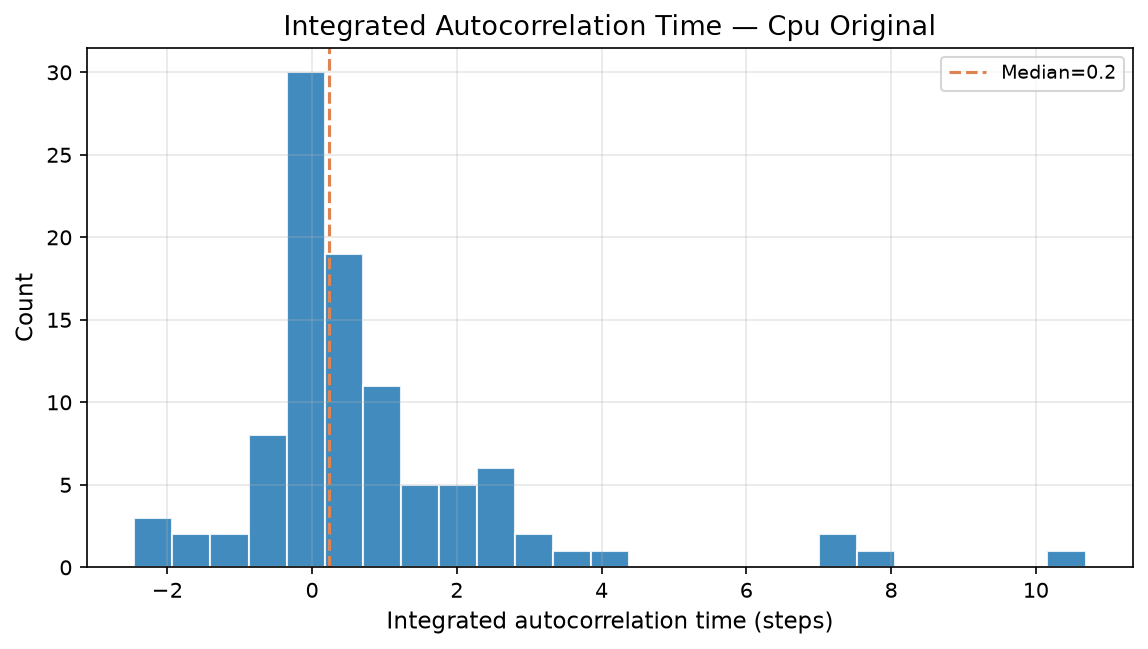

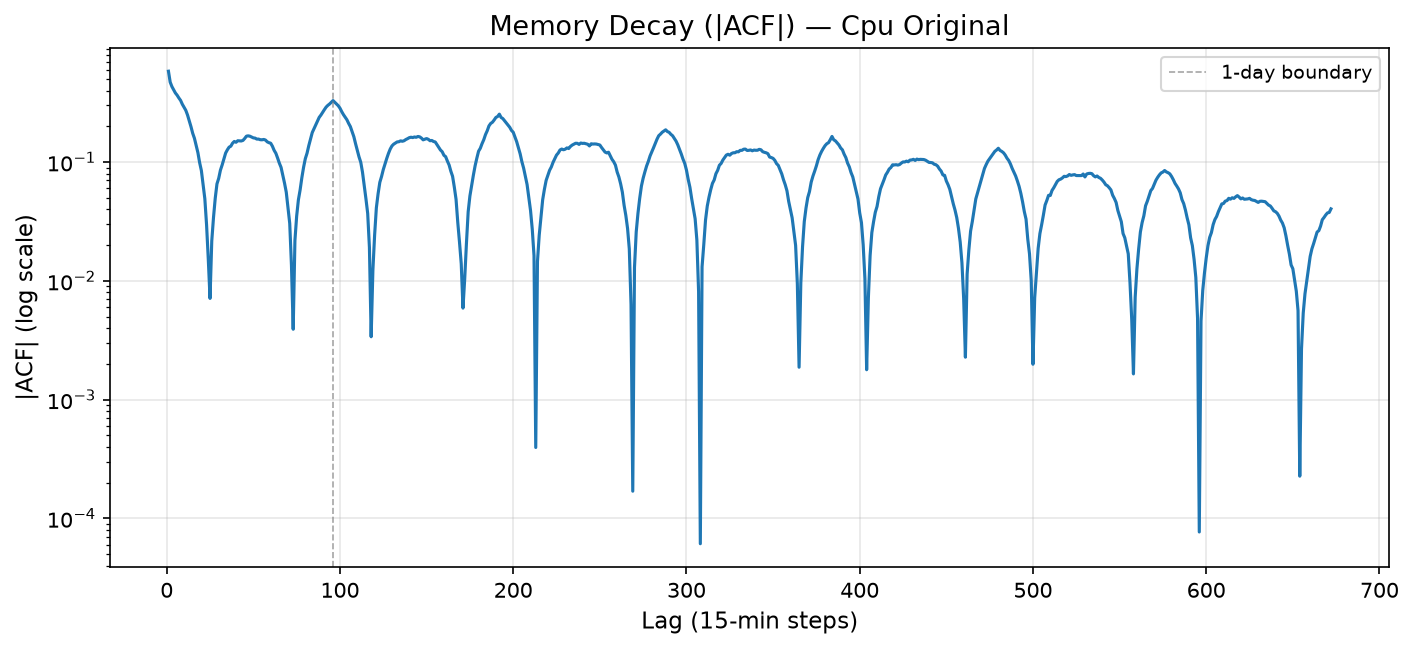

In [10]:
display(Image(filename=str(EXP_DIR / 'plots' / 'memory_length_hist_cpu_original.png')))
display(Image(filename=str(EXP_DIR / 'plots' / 'memory_decay_cpu_original.png')))

## 11. Window sufficiency

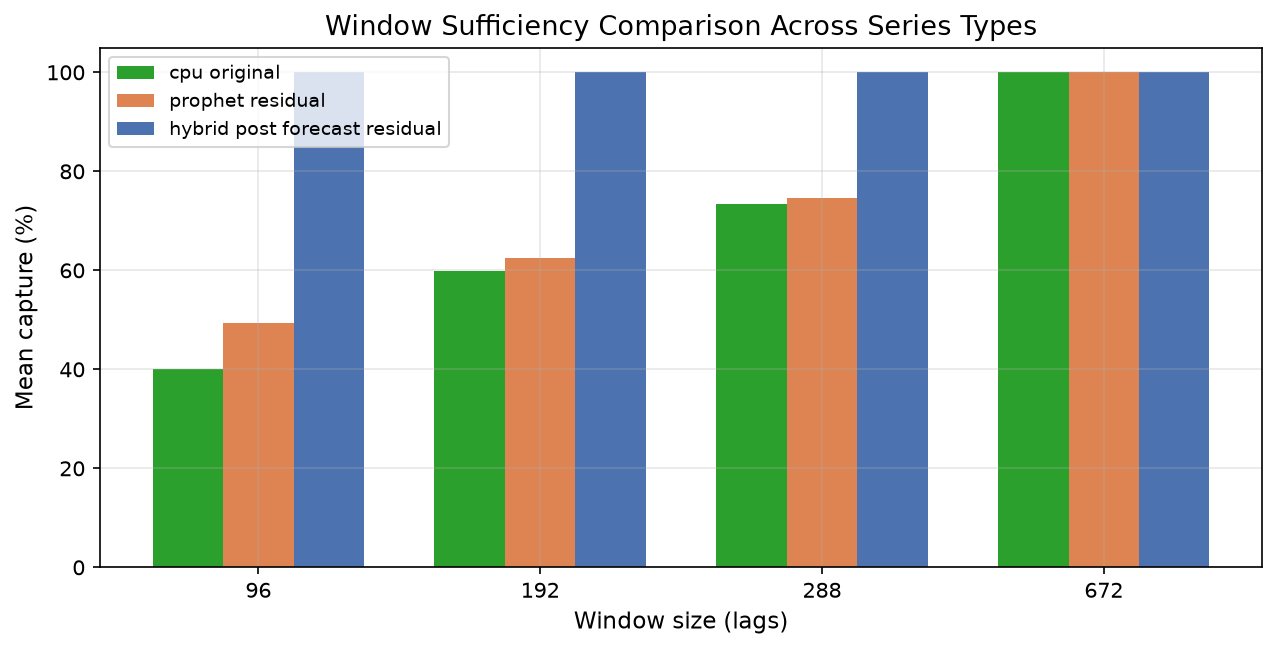

In [11]:
with (EXP_DIR / 'statistics' / 'cpu_original_window_sufficiency.json').open() as fh:
    window_suff = json.load(fh)
window_suff['cohort']
display(Image(filename=str(EXP_DIR / 'plots' / 'window_sufficiency_comparison.png')))

## 12. Case studies

In [12]:
with (EXP_DIR / 'statistics' / 'case_study_containers.json').open() as fh:
    case_studies = json.load(fh)
case_studies

{'weakest_long_memory': 'c_14471',
 'median_long_memory': 'c_10132',
 'strongest_long_memory': 'c_12231'}

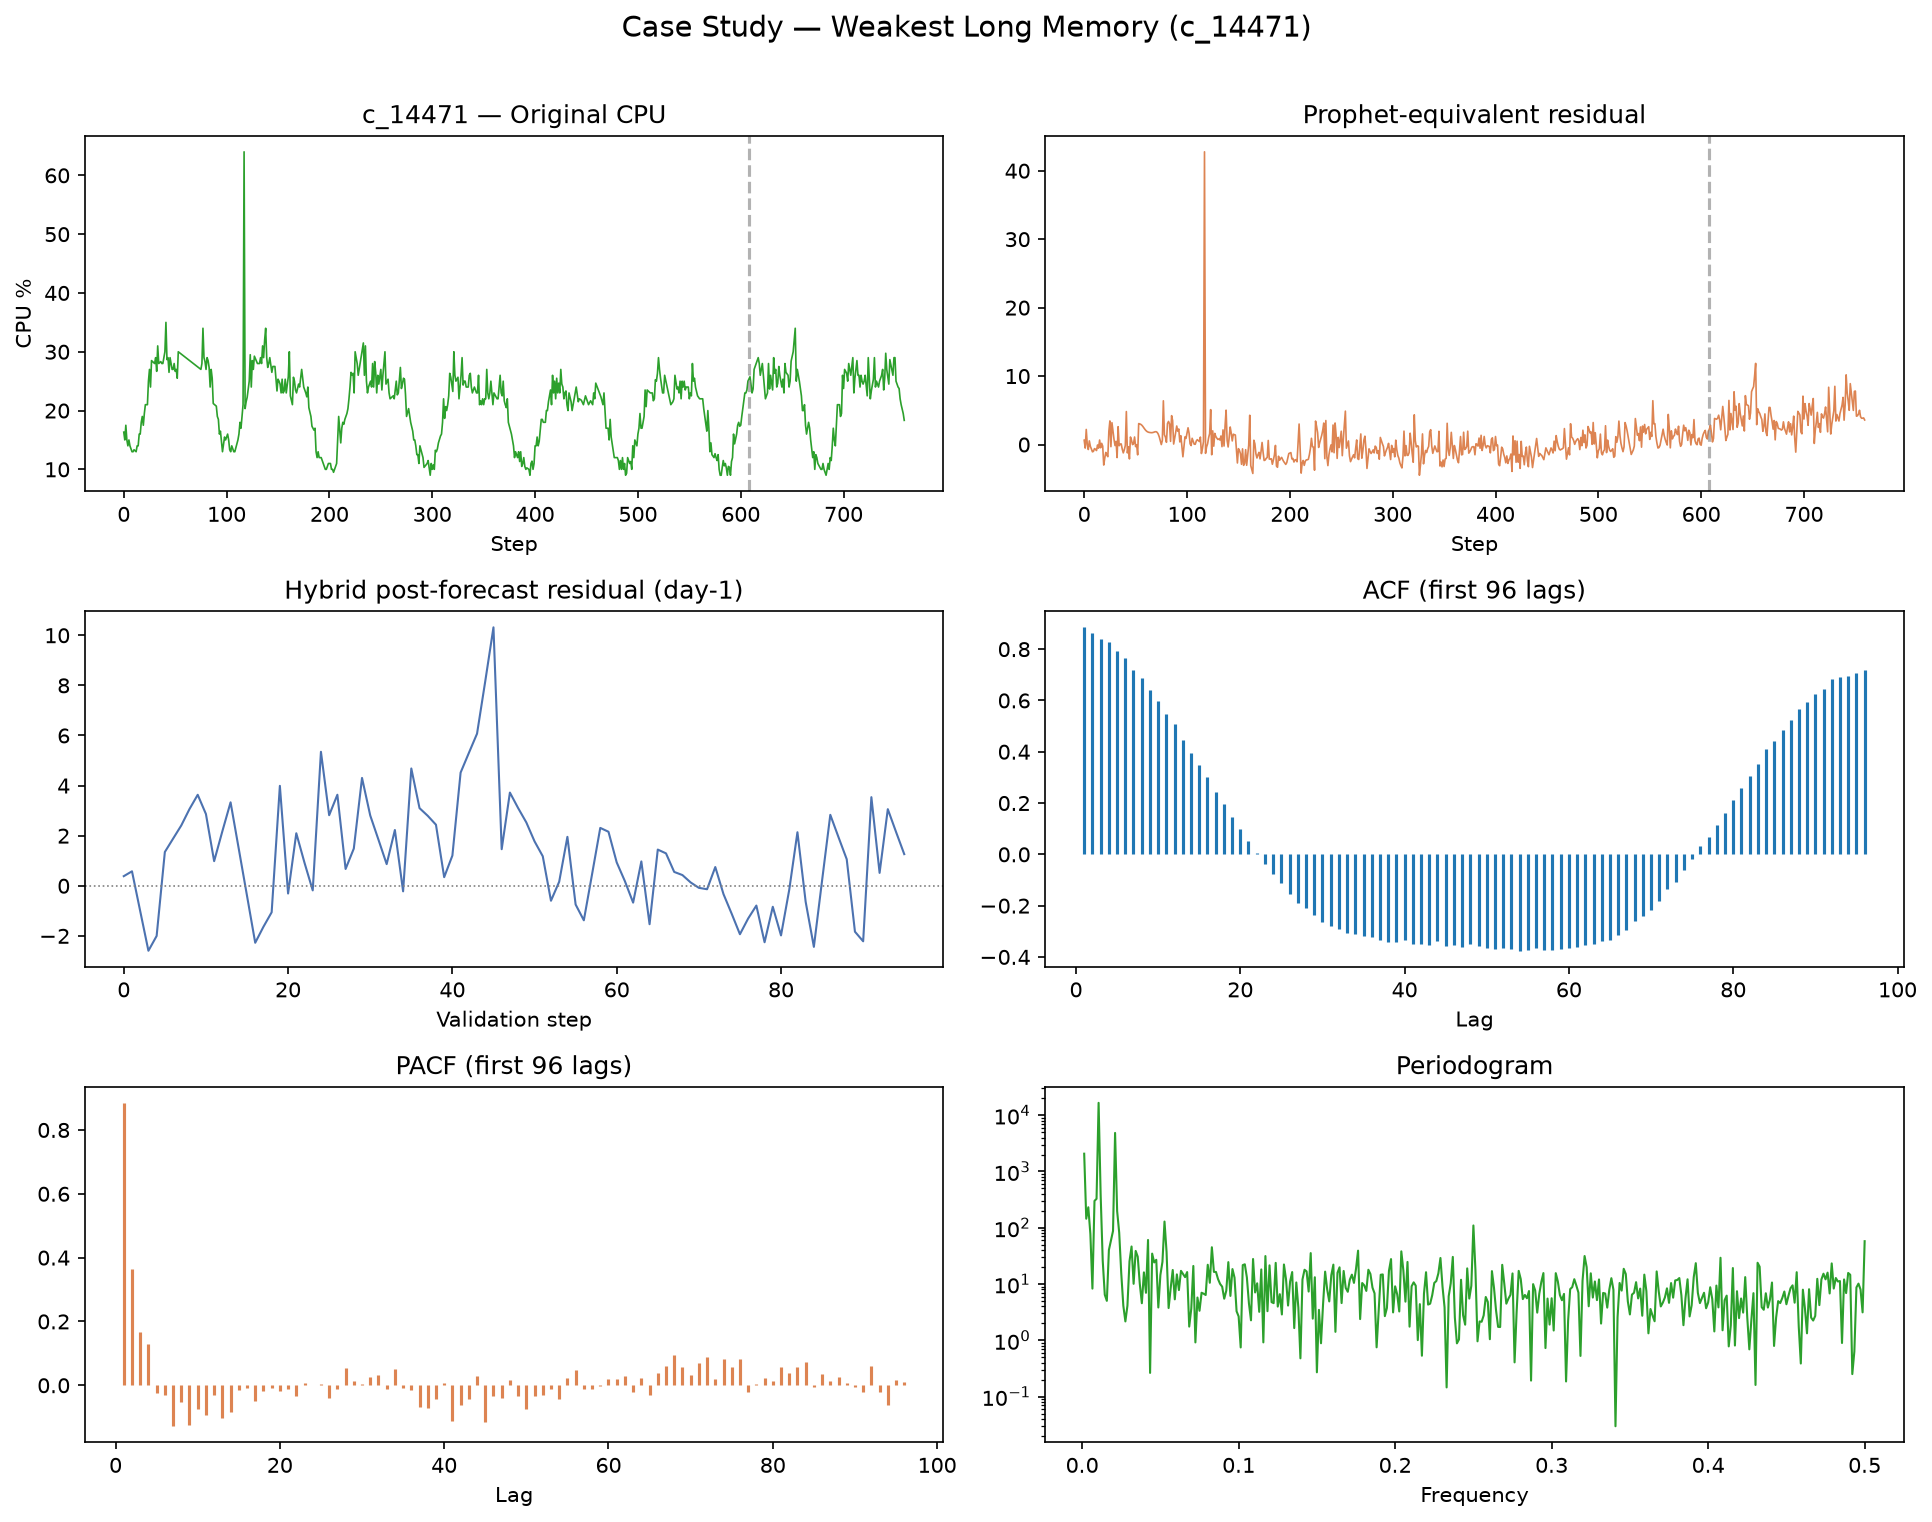

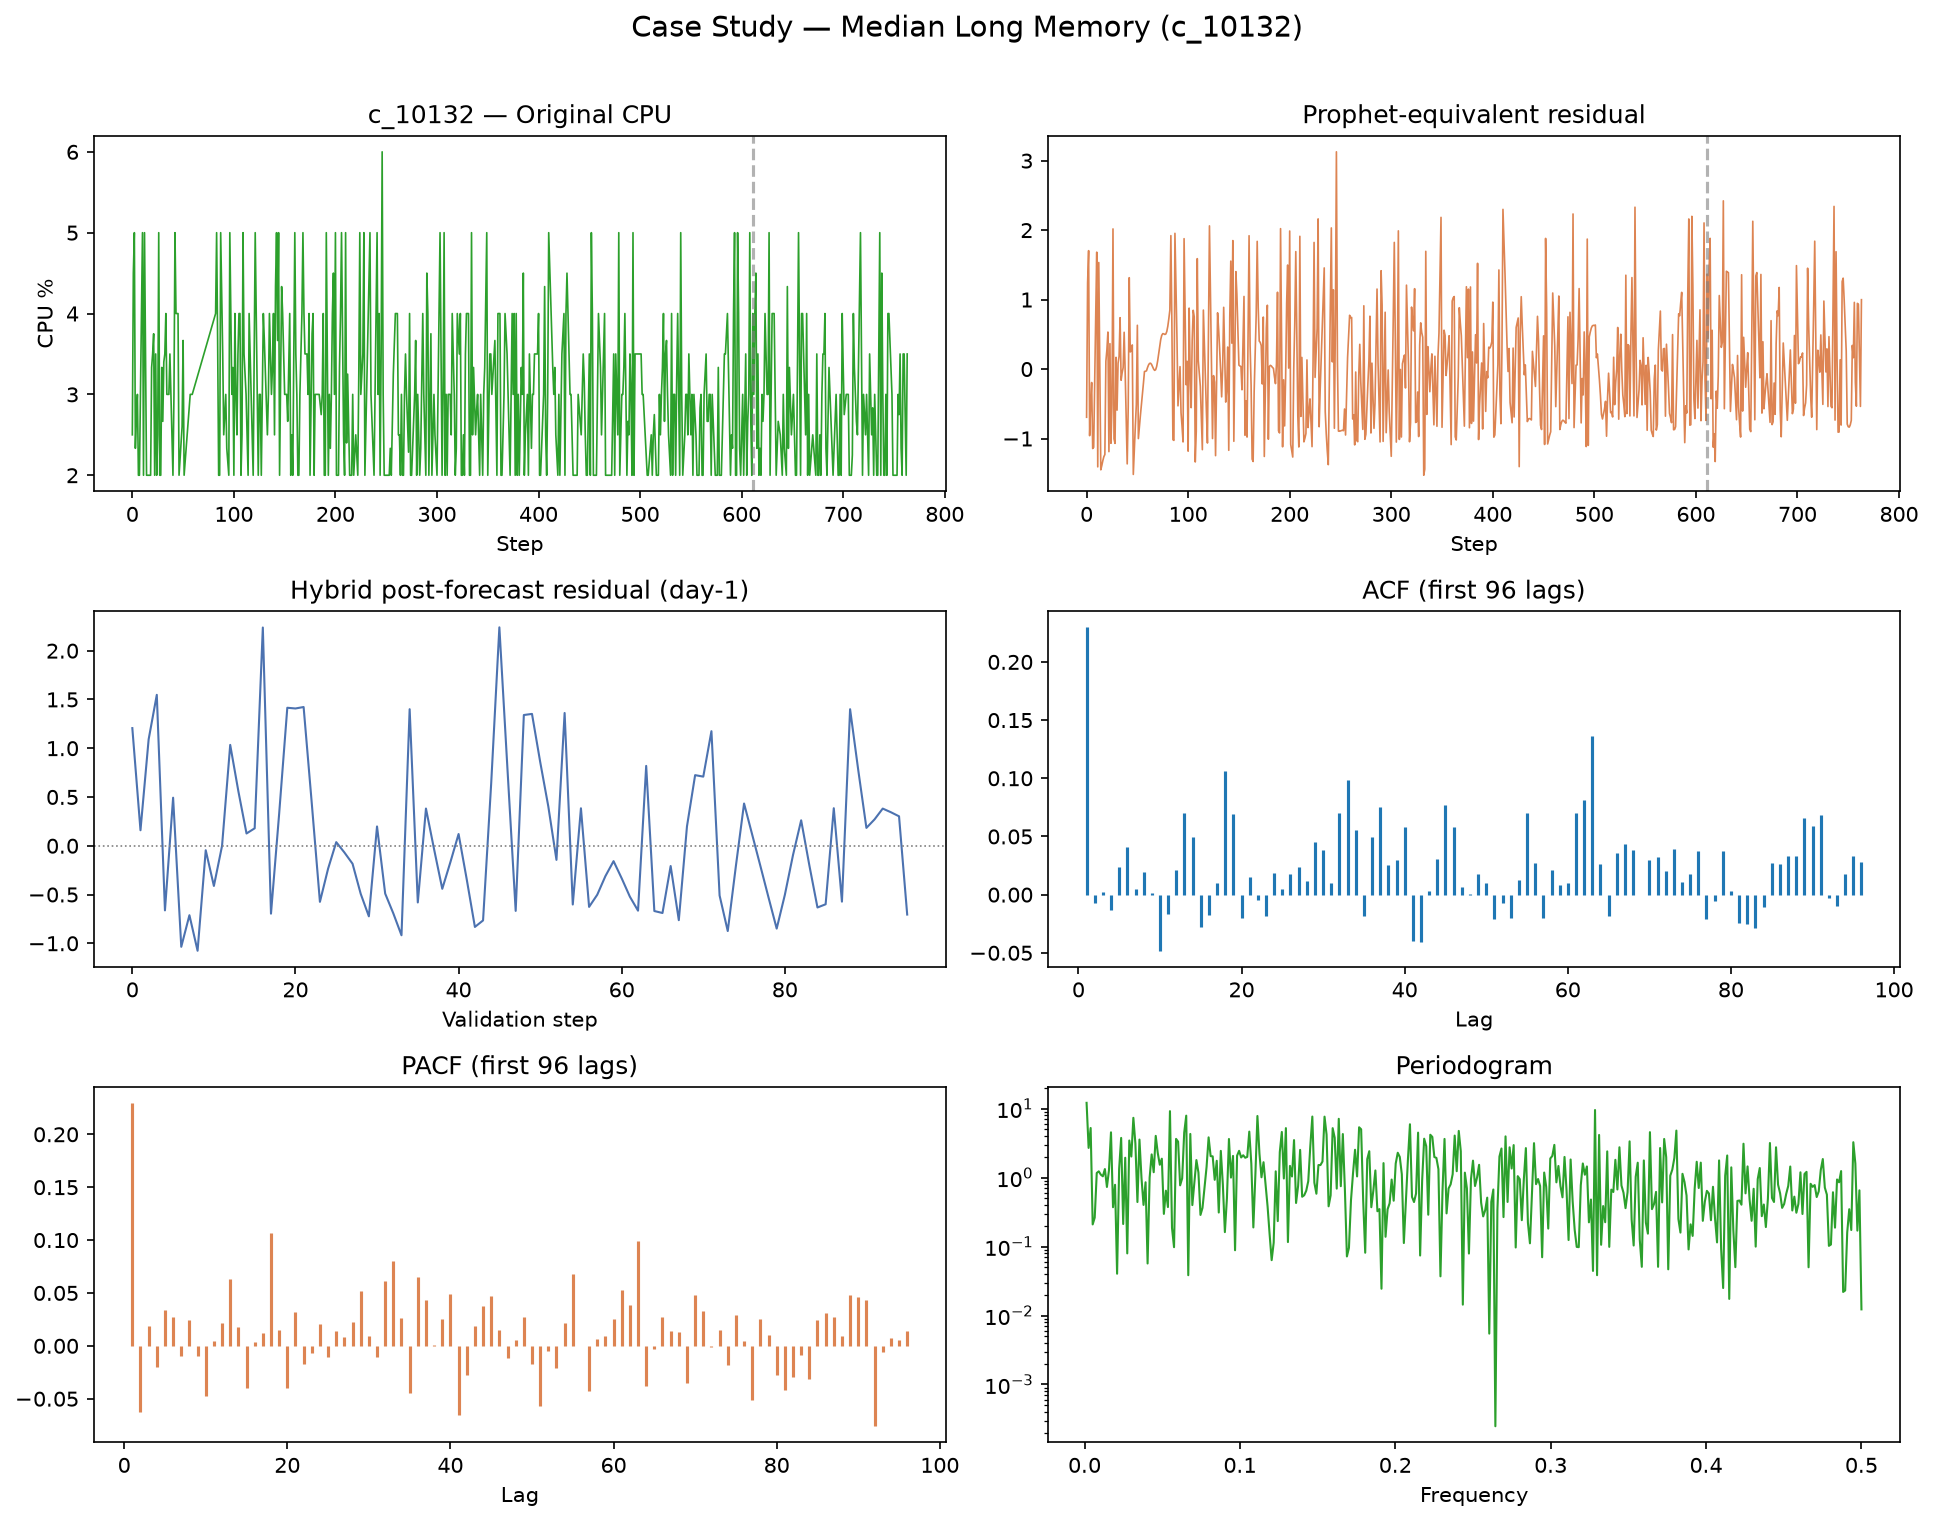

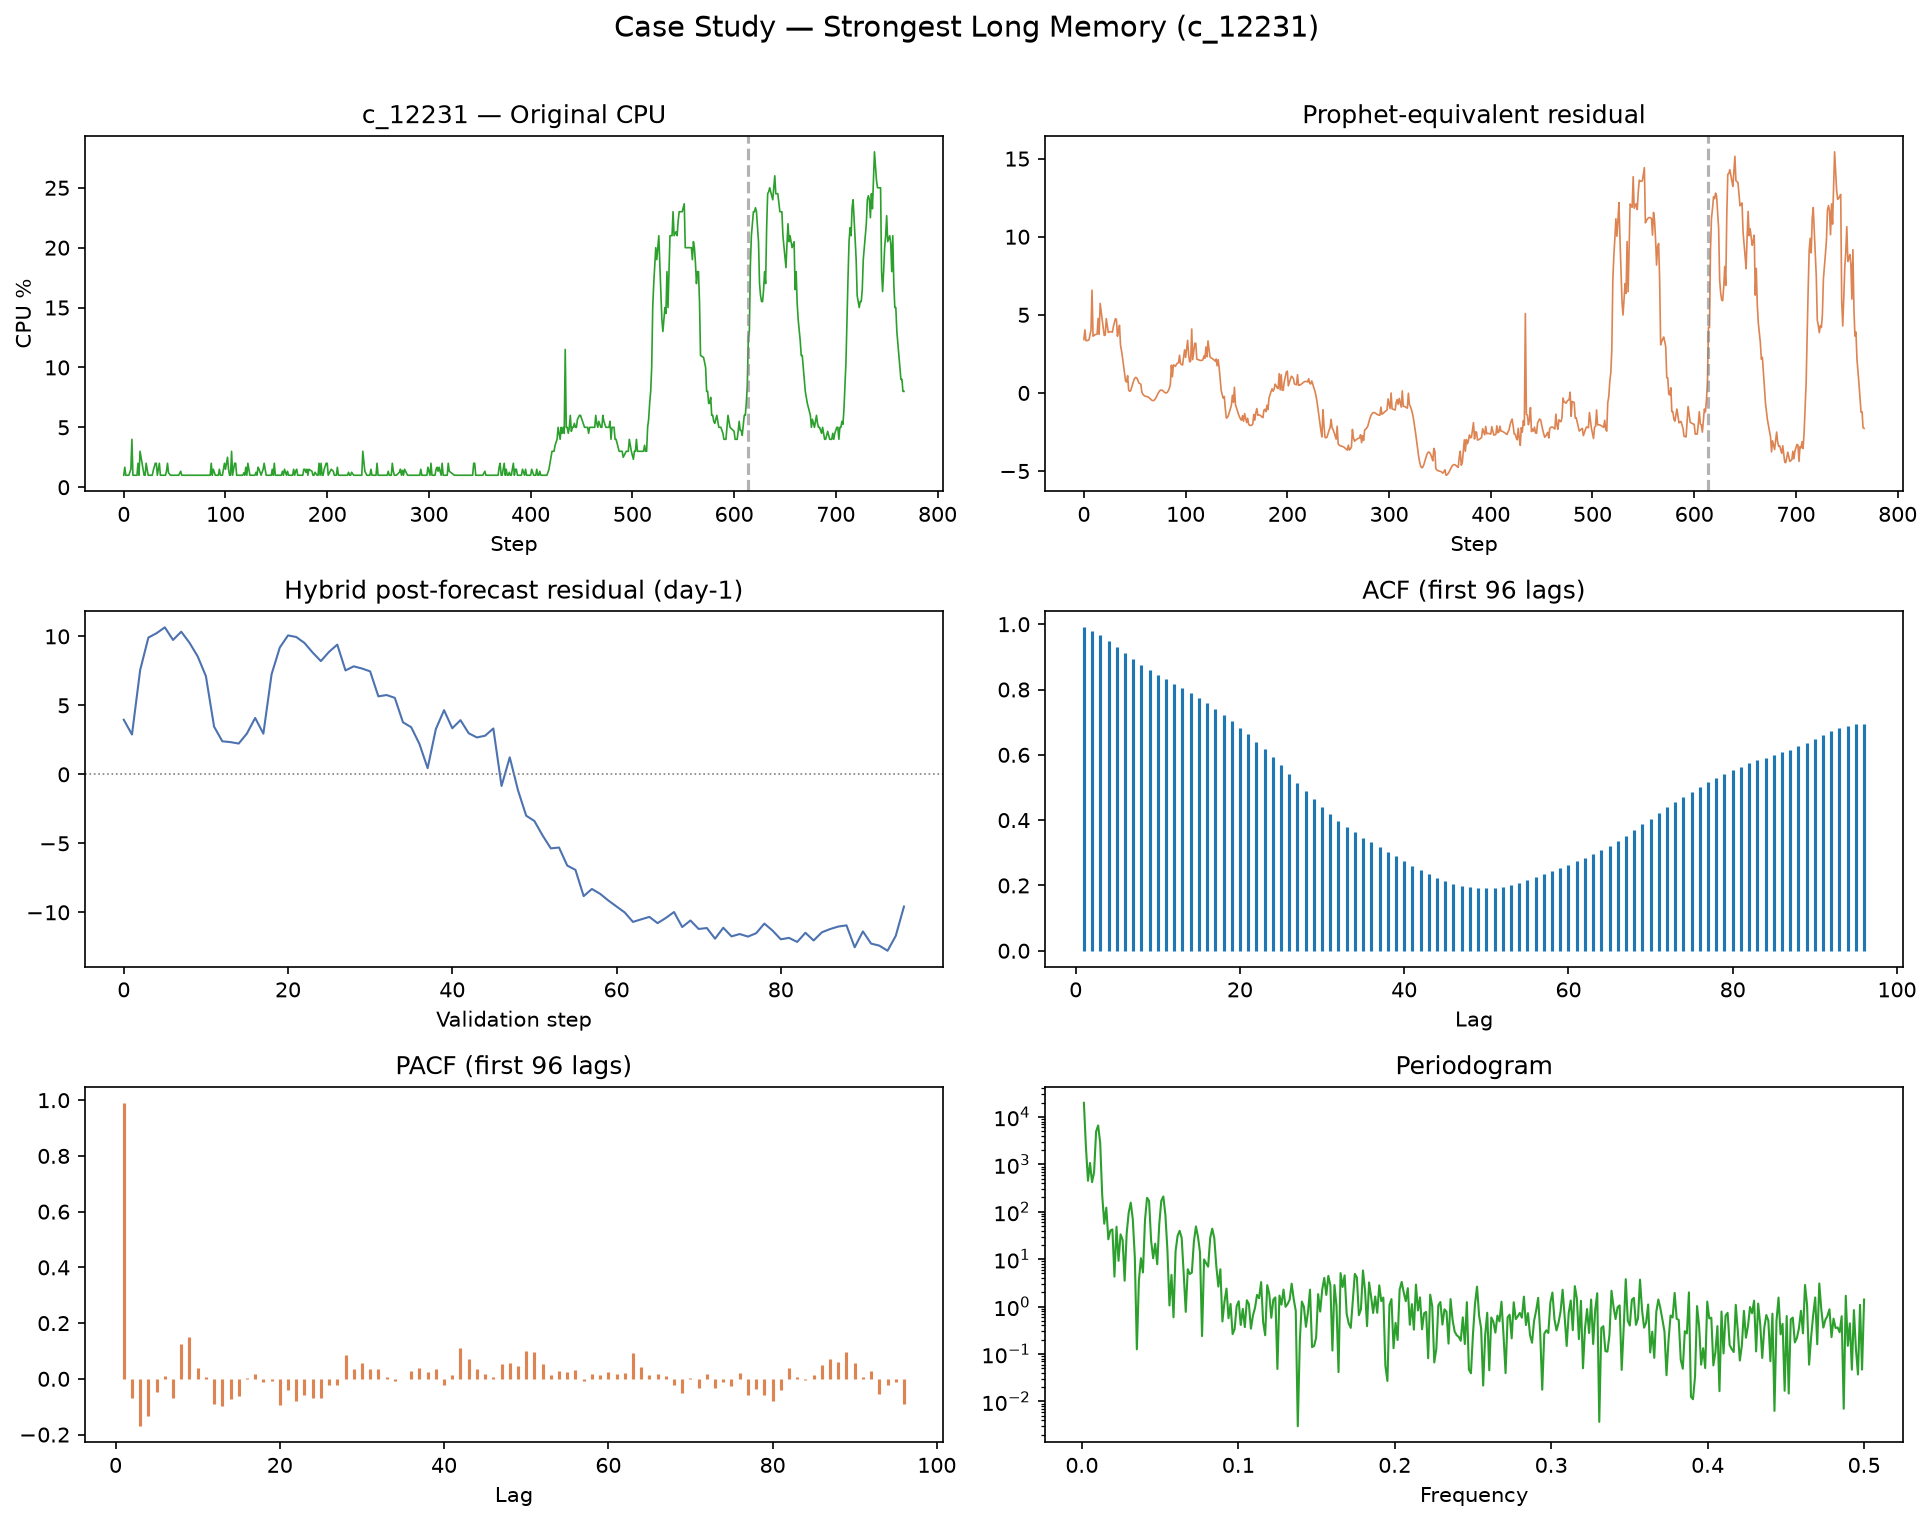

In [13]:
for role, cid in case_studies.items():
    path = EXP_DIR / 'plots' / f'case_study_{role}_{cid}.png'
    if path.exists():
        display(Image(filename=str(path)))

## 13. Discussion

In [14]:
with (EXP_DIR / 'statistics' / 'cpu_original_paired_day1_vs_beyond.json').open() as fh:
    paired = json.load(fh)
paired

{'n_pairs': 99,
 'mean_within': 0.19375944841850942,
 'mean_beyond': 0.09722647099673576,
 'mean_difference_beyond_minus_within': -0.0965329774217737,
 'wilcoxon_statistic': 0.0,
 'wilcoxon_pvalue': 5.697220948724935e-18,
 'cohens_dz': -1.130971633017246,
 'bootstrap_ci_difference_lo': -0.11294201405602669,
 'bootstrap_ci_difference_hi': -0.08002200200996681}

## 14. Final conclusions

In [15]:
for key, answer in final_report['explicit_answers'].items():
    print(f'\n{key}:\n{answer}')
print('\nVerdict:', final_report['verdict'])


q1_temporal_memory_magnitude:
Cohort integrated autocorrelation time (CPU) median = 0.24 steps; mean cumulative squared-ACF capture within 96 lags = 40.0%; lag-96 mean ACF = 0.329.

q2_dependence_beyond_one_day:
At lag 192 (2 days), mean ACF = 0.2533, 51.5% of containers have |ACF|≥0.1; paired beyond-vs-within mean |ACF| difference = -0.0965 (Wilcoxon p = 5.697e-18).

q3_daily_cycles_after_prophet:
After Prophet-equivalent decomposition, lag-96 mean ACF = 0.0420; mean daily-cycle PSD fraction = 0.0072.

q4_hybrid_long_range_dependence:
Hybrid day-1 post-forecast residual decorrelation lag (|ACF|<0.1) median = 3.0 steps (96-step series); within-96 capture = 100.0% when defined.

q5_was_96_step_window_sufficient:
On full timeline CPU, mean cumulative squared-ACF capture: 96 lags = 40.0%, 672 lags = 100.0%; gap beyond 96 lags = 60.0 percentage points.

q6_longer_window_information:
Available mean |ACF| within window — 96: 0.1938, 384: 0.1430; increment 96→384 = -0.0507 (information proxy